In [2]:
import pymysql
import pandas as pd

In [3]:
def push(query):
    try:
        connection = pymysql.connect(
            host='localhost',
            port=3306,
            user='root',
            password='lolik`12*-',
            database='stepik',
            cursorclass=pymysql.cursors.DictCursor,
        )
        print('Succesfully connect')
        print('#' * 20)

        try:
            with connection.cursor() as cursor:
                cursor.execute(query)
                print(f'{' '.join(query.split()[:2])} succesfully')
                if query.split()[0].lower() in ['select', 'show']:
                    return cursor
                if query.split()[0].lower() in ['insert', 'update', 'delete']:
                    connection.commit()

        finally:
            connection.close()

    except Exception as ex:
        print('Connection refused...')
        print(ex)

In [4]:
# Команды из набора DDL – Data Definition Language (язык описания данных):
# ALTER
# CREATE
# DROP

# Команды из набора DML – Data Manipulation Language (язык манипулирования данными):
# SELECT – выборка данных
# INSERT – вставка новых данных
# UPDATE – обновление данных
# DELETE – удаление данных
# MERGE – слияние данных

# 2. Проектирование БД (команды DDL)

In [5]:
# Удаление всех таблиц

push('DROP TABLE IF EXISTS channel_subscribers')
push('DROP TABLE IF EXISTS channels')
push('DROP TABLE IF EXISTS group_messages')
push('DROP TABLE IF EXISTS `groups`')
push('DROP TABLE IF EXISTS private_messages')
push('DROP TABLE IF EXISTS stories_likes')
push('DROP TABLE IF EXISTS stories')
push('DROP TABLE IF EXISTS user_settings')
push('DROP TABLE IF EXISTS languages')
push('DROP TABLE IF EXISTS users')

Succesfully connect
####################
DROP TABLE succesfully
Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'channels' referenced by a foreign key constraint 'channel_messages_ibfk_2' on table 'channel_messages'.")
Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'group_messages' referenced by a foreign key constraint 'group_message_reactions_ibfk_2' on table 'group_message_reactions'.")
Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'groups' referenced by a foreign key constraint 'group_members_ibfk_2' on table 'group_members'.")
Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'private_messages' referenced by a foreign key constraint 'private_message_reactions_ibfk_2' on table 'private_message_reactions'.")
Succesfully connect
####################
DROP TABLE succesfully
Succesfully connect
####################
DROP TABL

In [6]:
# Создание таблицы users
create_table_query = """
CREATE TABLE users(
    id BIGINT UNSIGNED NOT NULL AUTO_INCREMENT PRIMARY KEY,
    firstname VARCHAR(100),
    lastname VARCHAR(100) COMMENT 'фамилия',
    login VARCHAR(100),
    email VARCHAR(100) UNIQUE,
    password_hash VARCHAR(256),
    phone BIGINT UNSIGNED UNIQUE,
    birthday DATE,
    
    INDEX idx_users_username(firstname, lastname)
) COMMENT 'пользователи';"""

push(create_table_query)

Succesfully connect
####################
Connection refused...
(1050, "Table 'users' already exists")


In [7]:
# Удаление таблицы
drop_table_query = 'DROP TABLE IF EXISTS user_settings'
push(drop_table_query)

Succesfully connect
####################
DROP TABLE succesfully


In [8]:
# Создание таблицы user_settings

# 1 x 1
create_table_query = """
CREATE TABLE user_settings(
    user_id BIGINT UNSIGNED NOT NULL,
    is_premium_account BIT,
    is_night_mode_enabled BIT,
    color_scheme ENUM('classic', 'day', 'tinted', 'night'),
    LANGUAGE ENUM('english', 'french', 'russian', 'german', 'belorussian', 'croatian', 'dutch'),
    status_text VARCHAR(70),
    notifications_and_sounds JSON,
    created_at DATETIME DEFAULT NOW()
);"""

push(create_table_query)

Succesfully connect
####################
CREATE TABLE succesfully


In [9]:
# Создание связи с таблицами user_settings и users
alter_table_query = """
ALTER TABLE user_settings ADD CONSTRAINT fk_user_settings_user_id
FOREIGN KEY (user_id) REFERENCES users(id)
ON UPDATE CASCADE
ON DELETE RESTRICT;
"""

push(alter_table_query)

Succesfully connect
####################
ALTER TABLE succesfully


In [10]:
# Добавление строки в таблицу users

# insert_query = "INSERT INTO users (id, firstname, lastname, email, phone) VALUES ('2', 'Kelsie', 'Olson', 'xheidenereich@example.net', '9548489264');"

# можно не указывать автоинкрементное (AUTO_INCREMENT) поле
insert_query = """INSERT INTO users (firstname, lastname, email, phone, birthday) VALUES
('Ozella', 'Hauck', 'idickens@example.com', '9773438197', '1997-01-01'),
('Emmet', 'Hammes', 'qcremin@example.org', '9694110645', '1993-01-01'),
('Lori', 'Koch', 'damaris34@example.net', '9192291407', '1995-01-01'),
('Sam', 'Kuphal', 'telly.miller@example.net', '9917826315', '1999-01-01');"""

push(insert_query)

Succesfully connect
####################
INSERT INTO succesfully


In [11]:
# Запрос селект
select_query = 'SELECT * FROM users'
rows = push(select_query).fetchall()
for row in rows:
    print(row)

Succesfully connect
####################
SELECT * succesfully
{'id': 10, 'firstname': 'Ozella', 'lastname': 'Hauck', 'login': None, 'email': 'idickens@example.com', 'password_hash': None, 'phone': 9773438197, 'birthday': datetime.date(1997, 1, 1)}
{'id': 11, 'firstname': 'Emmet', 'lastname': 'Hammes', 'login': None, 'email': 'qcremin@example.org', 'password_hash': None, 'phone': 9694110645, 'birthday': datetime.date(1993, 1, 1)}
{'id': 12, 'firstname': 'Lori', 'lastname': 'Koch', 'login': None, 'email': 'damaris34@example.net', 'password_hash': None, 'phone': 9192291407, 'birthday': datetime.date(1995, 1, 1)}
{'id': 13, 'firstname': 'Sam', 'lastname': 'Kuphal', 'login': None, 'email': 'telly.miller@example.net', 'password_hash': None, 'phone': 9917826315, 'birthday': datetime.date(1999, 1, 1)}


In [12]:
# Удаление строк
drop_row_query = 'DELETE FROM users WHERE id IN (1, 2)'
push(drop_row_query)

Succesfully connect
####################
DELETE FROM succesfully


In [13]:
# Добавление, изменение типа, переименование, удавление полей таблицы
add_column_query = "ALTER TABLE users ADD COLUMN birthday DATETIME"
push(add_column_query)

modify_column_query = "ALTER TABLE users MODIFY COLUMN birthday DATE"
push(modify_column_query)

rename_column_query = "ALTER TABLE users RENAME COLUMN birthday to date_of_birth"
push(rename_column_query)

# drop_column_query = "ALTER TABLE users DROP COLUMN date_of_birth"
# push(drop_column_query)

Succesfully connect
####################
Connection refused...
(1060, "Duplicate column name 'birthday'")
Succesfully connect
####################
ALTER TABLE succesfully
Succesfully connect
####################
ALTER TABLE succesfully


In [14]:
pd.DataFrame(rows)

,id,firstname,lastname,login,email,password_hash,phone,birthday
0,10,Ozella,Hauck,None,idickens@example.com,None,9773438197,1997-01-01
1,11,Emmet,Hammes,None,qcremin@example.org,None,9694110645,1993-01-01
2,12,Lori,Koch,None,damaris34@example.net,None,9192291407,1995-01-01
3,13,Sam,Kuphal,None,telly.miller@example.net,None,9917826315,1999-01-01


In [15]:
# Изменение полей в user_settings
add_property_query = "ALTER TABLE user_settings ADD PRIMARY KEY (user_id)"
push(add_property_query)

# modify_column_query = "ALTER TABLE user_settings MODIFY COLUMN user_id BIGINT UNSIGNED NOT NULL PRIMATY KEY"
# push(modify_column_query)

rename_column_query = "ALTER TABLE user_settings RENAME COLUMN LANGUAGE to app_language"
push(rename_column_query)

Succesfully connect
####################
ALTER TABLE succesfully
Succesfully connect
####################
ALTER TABLE succesfully


In [16]:
# Создание таблицы private_messages

push('DROP TABLE IF EXISTS private_messages;')

# 1 x M
create_table_query = """
CREATE TABLE private_messages(
    id SERIAL,
    sender_id BIGINT UNSIGNED NOT NULL,
    receiver_id BIGINT UNSIGNED NOT NULL,
    reply_to_id BIGINT UNSIGNED NULL,
    media_type ENUM('text', 'image', 'audio', 'video'),
    body TEXT,
    filename VARCHAR(200),
    created_at DATETIME DEFAULT NOW(),

    FOREIGN KEY (sender_id) REFERENCES users(id),
    FOREIGN KEY (receiver_id) REFERENCES users(id),
    FOREIGN KEY (reply_to_id) REFERENCES private_messages(id)
);
"""
push(create_table_query)

Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'private_messages' referenced by a foreign key constraint 'private_message_reactions_ibfk_2' on table 'private_message_reactions'.")
Succesfully connect
####################
Connection refused...
(1050, "Table 'private_messages' already exists")


In [17]:
# Создание таблицы groups

push('DROP TABLE IF EXISTS `groups`;')

create_table_query = """
CREATE TABLE `groups` (
    id SERIAL,
    title VARCHAR(45),
    icon VARCHAR(45),
    invite_link VARCHAR(100),
    settings JSON,
    owner_user_id BIGINT UNSIGNED NOT NULL,
    is_private BIT,
    created_at DATETIME DEFAULT NOW(),

    FOREIGN KEY (owner_user_id) REFERENCES users (id)
);
"""

push(create_table_query)

Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'groups' referenced by a foreign key constraint 'group_members_ibfk_2' on table 'group_members'.")
Succesfully connect
####################
Connection refused...
(1050, "Table 'groups' already exists")


In [18]:
# Создание таблицы group_messages

push('DROP TABLE IF EXISTS `group_messages`;')

create_table_query = """
CREATE TABLE `group_messages` (
    id SERIAL,
    group_id BIGINT UNSIGNED NOT NULL,
    sender_id BIGINT UNSIGNED NOT NULL,
    reply_to_id BIGINT UNSIGNED NULL,
    media_type ENUM('text', 'image', 'audio', 'video'),
    body TEXT,
    filename VARCHAR(100) NULL,
    created_at DATETIME DEFAULT NOW(),

    FOREIGN KEY (sender_id) REFERENCES users (id),
    FOREIGN KEY (group_id) REFERENCES `groups` (id),
    FOREIGN KEY (reply_to_id) REFERENCES group_messages (id)
);
"""
push(create_table_query)

Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'group_messages' referenced by a foreign key constraint 'group_message_reactions_ibfk_2' on table 'group_message_reactions'.")
Succesfully connect
####################
Connection refused...
(1050, "Table 'group_messages' already exists")


In [19]:
# Создание таблицы channels

push('DROP TABLE IF EXISTS `channels`;')

create_table_query = """
CREATE TABLE channels (
    id SERIAL,
    title VARCHAR(45),
    icon VARCHAR(45),
    invite_link VARCHAR(100),
    settings JSON,
    owner_user_id BIGINT UNSIGNED NOT NULL,
    is_private BIT,
    created_at DATETIME DEFAULT NOW(),
    
    FOREIGN KEY (owner_user_id) REFERENCES users (id)    
);
"""
push(create_table_query)

Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'channels' referenced by a foreign key constraint 'channel_messages_ibfk_2' on table 'channel_messages'.")
Succesfully connect
####################
Connection refused...
(1050, "Table 'channels' already exists")


In [20]:
# Создание таблицы group_messages

push('DROP TABLE IF EXISTS `channel_subscribers`;')

# M x M
create_table_query = """
CREATE TABLE channel_subscribers (
    channel_id BIGINT UNSIGNED NOT NULL,
    user_id BIGINT UNSIGNED NOT NULL,
    status ENUM('requested', 'joined', 'left'),
    created_at DATETIME DEFAULT NOW(),
    updated_at DATETIME ON UPDATE CURRENT_TIMESTAMP,

    PRIMARY KEY (user_id, channel_id),
    FOREIGN KEY (user_id) REFERENCES users (id),
    FOREIGN KEY (channel_id) REFERENCES channels (id)
);
"""
push(create_table_query)

Succesfully connect
####################
DROP TABLE succesfully
Succesfully connect
####################
CREATE TABLE succesfully


In [21]:
# Создание таблицы group_messages

push('DROP TABLE IF EXISTS stories;')

create_table_query = """
CREATE TABLE stories (
    id SERIAL,
    user_id BIGINT UNSIGNED NOT NULL,
    caption VARCHAR(140),
    filename VARCHAR(100),
    views_count INT UNSIGNED,
    created_at DATETIME DEFAULT NOW(),

    FOREIGN KEY (user_id) REFERENCES users (id)
);
"""
push(create_table_query)

Succesfully connect
####################
DROP TABLE succesfully
Succesfully connect
####################
CREATE TABLE succesfully


In [22]:
# Создание таблицы group_messages

push('DROP TABLE IF EXISTS stories_likes;')

create_table_query = """
CREATE TABLE stories_likes (
	id SERIAL,
	story_id BIGINT UNSIGNED NOT NULL,
	user_id BIGINT UNSIGNED NOT NULL,
	created_at DATETIME DEFAULT NOW(),

	FOREIGN KEY (user_id) REFERENCES users (id),		
	FOREIGN KEY (story_id) REFERENCES stories (id)
);"""

push(create_table_query)

Succesfully connect
####################
DROP TABLE succesfully
Succesfully connect
####################
CREATE TABLE succesfully


In [23]:
# В связи с активным развитием проекта принято архитектурное решение вынести информацию о языках приложения 
# из поля app_language в таблице user_settings в отдельную таблицу-справочник языков.

# Архитектор обосновывает решение тем, что при добавлении нового языка в платформу проще добавить новую строку в таблицу, 
# чем изменять существующее поле в таблице.

In [24]:
# Сначала создадим таблицу languages.

# Поля:
# id - целочисленный первичный ключ (для простоты договоримся использовать псевдотип SERIAL)
# name - строка, название языка (содержит только уникальные значения, не может быть пустым)

push('DROP TABLE IF EXISTS languages;')

create_table_query = """
CREATE TABLE languages (
    id SERIAL,
    name VARCHAR(100) NOT NULL UNIQUE
);
"""

push(create_table_query)

Succesfully connect
####################
DROP TABLE succesfully
Succesfully connect
####################
CREATE TABLE succesfully


In [25]:
# Теперь добавим новое поле language_id в таблицу user_settings.
# Тип данных нового поля должен строго совпадать с полем id в таблице languages.

add_column_query = """
ALTER TABLE user_settings 
ADD COLUMN language_id BIGINT UNSIGNED;
"""

push(add_column_query)

Succesfully connect
####################
ALTER TABLE succesfully


In [26]:
# Теперь необходимо сделать поле language_id в таблице user_settings внешним ключом, 
# ссылающимся на идентификатор строки в таблице languages.

add_foreign_key_query = """
ALTER TABLE user_settings
ADD CONSTRAINT fk_language_id_id
FOREIGN KEY (language_id) REFERENCES languages(id)
ON DELETE CASCADE
ON UPDATE CASCADE;
"""

push(add_foreign_key_query)

Succesfully connect
####################
ALTER TABLE succesfully


In [27]:
# Другие люди заполнили таблицу languages нужными данными и проставили правильные значения в поле language_id.
# Осталось удалить поле app_language из таблицы user_settings, потому что теперь оно лишь дублирует новый функционал.

drop_column_query = """
ALTER TABLE user_settings
DROP COLUMN app_language;
"""

push(drop_column_query)

Succesfully connect
####################
ALTER TABLE succesfully


# 3. Работа с данными (команды DML, CRUD)

## 3.1  Команда INSERT

In [28]:
# Очистка таблицы (пересоздаем)

truncate_query = 'TRUNCATE users'
push(truncate_query)

Succesfully connect
####################
Connection refused...
(1701, 'Cannot truncate a table referenced in a foreign key constraint (`stepik`.`private_messages`, CONSTRAINT `private_messages_ibfk_1`)')


In [29]:
# базовый вариант команды INSERT

insert_query = """
INSERT INTO users (id, firstname, lastname, email, phone, date_of_birth)
VALUES ('1', 'Kelsie', 'Olson', 'xheidenreich@example.net', '9548492646', '2000-01-01');"""

push(insert_query)

Succesfully connect
####################
INSERT INTO succesfully


In [30]:
# можно не указывать автоинкрементное (AUTO_INCREMENT) поле
insert_query = """
INSERT INTO users (firstname, lastname, email, phone, date_of_birth)
VALUES ('Celestino', 'Cruickshank', 'flavio.hammes2@example.com', '9686686722', '2011-01-01');"""

push(insert_query)

Succesfully connect
####################
INSERT INTO succesfully


In [31]:
# идентификаторы можно добавлять не по порядку
insert_query = """
INSERT INTO users (id, firstname, lastname, email, phone, date_of_birth)
VALUES ('93', 'Gregory', 'Jenkins', 'weimann.richard@example.com', '9860971258', '2011-01-01');"""

push(insert_query)

Succesfully connect
####################
INSERT INTO succesfully


In [32]:
# добавим колонку is_deleted
add_column_query = "ALTER TABLE users ADD COLUMN is_deleted BIT DEFAULT 0;"

push(add_column_query)

Succesfully connect
####################
ALTER TABLE succesfully


In [33]:
# значение по умолчанию для поля is_deleted
# insert_query = """
# INSERT INTO users (firstname, lastname, is_deleted)
# VALUES ('Celestino', 'Cruickshank', DEFAULT);"""

# push(insert_query)

In [34]:
# не указываем имена полей - рабочий вариант
insert_query = """
INSERT INTO users
VALUES (101, 'Eleonore', 'Ward', NULL, 'antonietta333@example.com',DEFAULT, 9397815333, '2000-01-01', 0);"""

push(insert_query)

Succesfully connect
####################
INSERT INTO succesfully


In [35]:
# пакетная вставка данных - работает быстро (одиночная вставка данных - работает медленно)
insert_query = """
INSERT INTO users (firstname, lastname, email, phone, date_of_birth) VALUES
('Ozella', 'Hauck', 'idickens@example.com', '9773438197', '1989-01-01'),
('Emmet', 'Hammes', 'qcremin@example.org', '9694110645', '1991-01-01'),
('Lori', 'Koch', 'damaris34@example.net', '9192291407', '1990-01-01'),
('Sam', 'Kuphal', 'telly.miller@example.net', '9917826315', '1995-01-01');"""

push(insert_query)

Succesfully connect
####################
Connection refused...
(1062, "Duplicate entry 'idickens@example.com' for key 'users.email'")


In [36]:
# второй вариант команды INSERT (можно вставить только 1 строку)
insert_query = """
INSERT INTO users
SET
    firstname = 'Miguel',
    lastname = 'Watsica',
    email = 'hassan.kuphal@example.org',
    login = 'hassan_kuphal',
    phone = '9824696112'
;"""

push(insert_query)

Succesfully connect
####################
INSERT INTO succesfully


In [37]:
# INSERT-SELECT
insert_query = """
INSERT INTO users
    (firstname, lastname, email, phone, date_of_birth)
SELECT
    'Sam2', 'Kuphal2', 'telly.miller222@example.net', '9917826222', '2021-01-01';"""

push(insert_query)

Succesfully connect
####################
INSERT INTO succesfully


In [38]:
# опция ON DUPLICATE KEY UPDATE позволяет выполнить обновление
insert_query = """
INSERT INTO users (id, firstname, lastname, email, phone, date_of_birth)
VALUES (2, 'Lucile', 'Rolfson', 'dbartell@example.net', 9258387168, '2021-01-01')
ON DUPLICATE KEY UPDATE
    firstname = 'Lucile',
    lastname = 'Rolfson',
    email = 'dbartell@example.net',
    phone = 9258387168
;"""

push(insert_query)

Succesfully connect
####################
INSERT INTO succesfully


## 3.2 Команда SELECT

In [39]:
# Вывод текста:
select_query = "SELECT 'Hello world';"

push(select_query)

Succesfully connect
####################
SELECT 'Hello succesfully


In [40]:
# вывести всю таблицу users (все поля, все строки):
select_query = """
SELECT *
FROM users;"""

pd.DataFrame(push(select_query)).head(5)

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,date_of_birth,is_deleted
0,1,Kelsie,Olson,None,xheidenreich@example.net,None,9548492646,2000-01-01,b'\x00'
1,2,Lucile,Rolfson,None,dbartell@example.net,None,9258387168,2021-01-01,b'\x00'
2,10,Ozella,Hauck,None,idickens@example.com,None,9773438197,1997-01-01,b'\x00'
3,11,Emmet,Hammes,None,qcremin@example.org,None,9694110645,1993-01-01,b'\x00'
4,12,Lori,Koch,None,damaris34@example.net,None,9192291407,1995-01-01,b'\x00'


In [41]:
# явно указываем поля, которые необходимо вывести:
select_query = """
SELECT id, firstname , lastname , login , email , password_hash , phone, is_deleted
FROM users;"""

pd.DataFrame(push(select_query)).head(5)

Succesfully connect
####################
SELECT id, succesfully


,id,firstname,lastname,login,email,password_hash,phone,is_deleted
0,1,Kelsie,Olson,None,xheidenreich@example.net,None,9548492646,b'\x00'
1,2,Lucile,Rolfson,None,dbartell@example.net,None,9258387168,b'\x00'
2,10,Ozella,Hauck,None,idickens@example.com,None,9773438197,b'\x00'
3,11,Emmet,Hammes,None,qcremin@example.org,None,9694110645,b'\x00'
4,12,Lori,Koch,None,damaris34@example.net,None,9192291407,b'\x00'


In [42]:
# выводим пользователя по его идентификатору (с лимитом 10 с сортировкой по имени):
select_query = """
SELECT *
FROM users
WHERE id < 5 or id IN (5, 7)
ORDER BY firstname DESC
LIMIT 10;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,date_of_birth,is_deleted
0,2,Lucile,Rolfson,None,dbartell@example.net,None,9258387168,2021-01-01,b'\x00'
1,1,Kelsie,Olson,None,xheidenreich@example.net,None,9548492646,2000-01-01,b'\x00'


In [43]:
# выводим количество строк с указанным именем:
select_query = """
SELECT count(firstname)
FROM users;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT count(firstname) succesfully


,count(firstname)
0,11


In [44]:
# выводим количество строк с уникальными именами:
select_query = """
SELECT count(DISTINCT firstname) as DISTINCT_COUNT
FROM users;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT count(DISTINCT succesfully


,DISTINCT_COUNT
0,11


## 3.3 Команда UPDATE

In [45]:
# вставим новую строку в таблицу channels
# (создадим новый канал)

push("""INSERT INTO channels(title, invite_link, owner_user_id, is_private)
VALUES ('MySQL news', 'https://t.me/mysql_news', 1, true);""")


Succesfully connect
####################
INSERT INTO succesfully


In [46]:
# вставим новые строки в таблицу channel_subscribers
# (пользователи отправляют заявки на вступление в канал)
push("""INSERT INTO channel_subscribers(channel_id, user_id, status)
VALUES (1, 2, 'requested');""")
     
push("""INSERT INTO channel_subscribers(channel_id, user_id, status)
VALUES (1, 3, 'requested');""")

push("""INSERT INTO channel_subscribers(channel_id, user_id, status)
VALUES (1, 4, 'requested');""")

Succesfully connect
####################
Connection refused...
(1452, 'Cannot add or update a child row: a foreign key constraint fails (`stepik`.`channel_subscribers`, CONSTRAINT `channel_subscribers_ibfk_2` FOREIGN KEY (`channel_id`) REFERENCES `channels` (`id`))')
Succesfully connect
####################
Connection refused...
(1452, 'Cannot add or update a child row: a foreign key constraint fails (`stepik`.`channel_subscribers`, CONSTRAINT `channel_subscribers_ibfk_1` FOREIGN KEY (`user_id`) REFERENCES `users` (`id`))')
Succesfully connect
####################
Connection refused...
(1452, 'Cannot add or update a child row: a foreign key constraint fails (`stepik`.`channel_subscribers`, CONSTRAINT `channel_subscribers_ibfk_1` FOREIGN KEY (`user_id`) REFERENCES `users` (`id`))')


In [47]:
# обновит все строки в таблице channel_subscribers (плохо!)
push("""UPDATE channel_subscribers
SET
    status = 'joined';""")

Succesfully connect
####################
UPDATE channel_subscribers succesfully


In [48]:
# админ подтверждает добавление подписчика в канал
push("""UPDATE channel_subscribers
SET
    status = 'joined'
WHERE channel_id = 1 AND user_id = 2;""")

push("""UPDATE channel_subscribers
SET
    status = 'joined'
WHERE channel_id = 1 AND user_id = 3;""")

Succesfully connect
####################
UPDATE channel_subscribers succesfully
Succesfully connect
####################
UPDATE channel_subscribers succesfully


In [49]:
# пользователь покидает канал
push("""UPDATE channel_subscribers
SET
    status = 'left'
WHERE channel_id = 1 AND user_id = 2;""")

Succesfully connect
####################
UPDATE channel_subscribers succesfully


In [50]:
# добавим новый статус 'удален'
push("""ALTER TABLE channel_subscribers
MODIFY COLUMN status ENUM('requested', 'joined', 'left', 'removed');""")

Succesfully connect
####################
ALTER TABLE succesfully


In [51]:
# пользователя принудительно удалили из канала
push("""UPDATE channel_subscribers
SET
    status = 'removed'
WHERE channel_id = 1 AND user_id = 4;""")

Succesfully connect
####################
UPDATE channel_subscribers succesfully


In [52]:
# переименуем канал
push("""UPDATE channels
SET title = 'General SQL news'
WHERE id = 1;""")

Succesfully connect
####################
UPDATE channels succesfully


In [53]:
pd.DataFrame(push("SELECT * FROM channel_subscribers"))

Succesfully connect
####################
SELECT * succesfully


""


## 3.4 Команда DELETE

In [54]:
# удаляем все строки из таблицы сообщений 
# (очищает данные, индексация сохраняется после удаления данных)

push("DELETE FROM private_messages;")

Succesfully connect
####################
DELETE FROM succesfully


In [55]:
# пересоздаем таблицу сообщений (DROP-CREATE)
# (пересоздается таблица, индексация следовательно обнуляется)

push("TRUNCATE private_messages;")

Succesfully connect
####################
Connection refused...
(1701, 'Cannot truncate a table referenced in a foreign key constraint (`stepik`.`private_message_reactions`, CONSTRAINT `private_message_reactions_ibfk_2`)')


In [56]:
columns = push('SHOW COLUMNS FROM private_messages')

fields_df = pd.DataFrame(columns)
fields_df

Succesfully connect
####################
SHOW COLUMNS succesfully


,Field,Type,Null,Key,Default,Extra
0,id,bigint unsigned,NO,PRI,None,auto_increment
1,sender_id,bigint unsigned,NO,MUL,None,
2,receiver_id,bigint unsigned,NO,MUL,None,
3,reply_to_id,bigint unsigned,YES,MUL,None,
4,media_type,"enum('text','image','audio','video')",YES,,None,
5,body,text,YES,,None,
6,filename,varchar(200),YES,,None,
7,created_at,datetime,YES,,CURRENT_TIMESTAMP,DEFAULT_GENERATED


In [57]:
print(fields_df['Field'].to_list())

['id', 'sender_id', 'receiver_id', 'reply_to_id', 'media_type', 'body', 'filename', 'created_at']


In [58]:
push("DROP TABLE IF EXISTS `private_messages`;")
     
create_table_query = """
CREATE TABLE `private_messages`(
    `id` SERIAL,
    `sender_id` BIGINT UNSIGNED NOT NULL,
    `receiver_id` BIGINT UNSIGNED NOT NULL,
    `reply_to_id` BIGINT UNSIGNED NULL,
    `media_type` ENUM('text', 'image', 'audio', 'video'),
    `body` TEXT,
    `filename` VARCHAR(200),
    `created_at` DATETIME DEFAULT NOW(),

    FOREIGN KEY (sender_id) REFERENCES users(id),
    FOREIGN KEY (receiver_id) REFERENCES users(id),
    FOREIGN KEY (reply_to_id) REFERENCES private_messages(id) 

    

);"""

push(create_table_query)

Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'private_messages' referenced by a foreign key constraint 'private_message_reactions_ibfk_2' on table 'private_message_reactions'.")
Succesfully connect
####################
Connection refused...
(1050, "Table 'private_messages' already exists")


In [59]:
# подготовка данных (добавляем несколько сообщений между пользователями)
insert_query = """
INSERT INTO `private_messages`(sender_id, receiver_id, media_type, body, filename, created_at)
VALUES
(1,2,'text','Eveniet suscipit ullam occaecati consequatur hic. Nulla est in molestiae odit. Placeat perferendis consequatur qui omnis id vel autem.','officiis','2010-04-07 09:01:02'),
(2,1,'audio','Non repudiandae maiores molestiae vel doloribus. Quis facere blanditiis est magnam est ut vero.','qui','1971-05-29 07:31:20'),
(1,3,'text','Voluptas qui consequatur quae sunt et consequatur. Rem alias sed cupiditate explicabo voluptate. Officiis repellat porro accusamus eveniet quos. Laborum dolores sed enim aut.','excepturi','1998-10-28 20:08:01'),
(1,4,'video','Est delectus tempora exercitationem atque tempora reiciendis nulla voluptatem. Cupiditate non fugit blanditiis quasi ad et autem expedita. Aut est provident odio quasi possimus.','vitae','2001-12-03 15:54:43'),
(1,2,'video','Est ducimus amet et asperiores. Reiciendis debitis qui ipsa. Nemo laboriosam ea aut omnis voluptates quisquam accusantium. Quibusdam totam similique aut.','optio','1970-09-18 20:39:35'),
(1,2,'video','Quis cupiditate quis maxime et placeat consectetur ut quis. Voluptas unde voluptatem deserunt in dolorum maxime. Sunt fugiat sit tenetur placeat at.','laboriosam','1980-05-11 03:39:43'),
(2,1,'audio','Voluptatum nihil rem laboriosam delectus aperiam consequuntur et modi. Laudantium molestias corporis quo omnis ut ea. At minima iure et voluptatum culpa deleniti non. Sint laboriosam molestias dolor vel. Quibusdam omnis quas ullam dolor.','sit','1988-08-19 10:30:44'),
(2,4,'audio','Nemo eos sed aspernatur voluptates perspiciatis tenetur. Voluptas sunt magnam vero nam earum. Magnam eum vitae qui. Vel atque accusantium in non rem non et.','consectetur','1984-06-28 16:22:44'),
(4,5,'audio','Quod nihil possimus id qui. Quasi officia rerum eum doloribus est voluptas maxime. Et debitis enim non enim fugit.','repellat','1981-12-11 16:04:11'),
(3,1,'text','Qui voluptatem earum temporibus rem vel sequi. Et quasi vel qui est autem aliquam. Modi est voluptatem aut rerum ea velit. Voluptate et eligendi debitis nostrum nihil dolorum.','nihil','1988-02-16 13:29:14'),
(3,2,'image','Rem et ullam cum vitae autem reprehenderit quia. Enim a ipsam id ut aliquam est error. Quis dolorum omnis expedita eaque maiores illo.','et','2015-04-07 18:02:42')
;"""

push(insert_query)

Succesfully connect
####################
Connection refused...
(1452, 'Cannot add or update a child row: a foreign key constraint fails (`stepik`.`private_messages`, CONSTRAINT `private_messages_ibfk_2` FOREIGN KEY (`receiver_id`) REFERENCES `users` (`id`))')


In [60]:
pd.DataFrame(push("SELECT * FROM private_messages"))

Succesfully connect
####################
SELECT * succesfully


""


In [61]:
# удаляем сообщения от пользователя номер 1 к пользователю номер 2
delete_query = """
DELETE FROM private_messages
WHERE sender_id = 1 AND receiver_id IN (2, 4) OR sender_id = 2;"""

push(delete_query)

Succesfully connect
####################
DELETE FROM succesfully


In [62]:
pd.DataFrame(push("SELECT * FROM private_messages"))

Succesfully connect
####################
SELECT * succesfully


""


In [63]:
# пробуем удалить пользователя номер 3
push("""DELETE FROM users
WHERE id = 3;""")

Succesfully connect
####################
DELETE FROM succesfully


In [64]:
# сначала удаляем его подписки на каналы
push("""DELETE FROM channel_subscribers
WHERE user_id = 3;""")

Succesfully connect
####################
DELETE FROM succesfully


In [65]:
# удаляем сообщения пользователя номер 3
push("""DELETE FROM private_messages
WHERE sender_id = 3 OR receiver_id = 3;""")

Succesfully connect
####################
DELETE FROM succesfully


In [66]:
# добавим флаг для удаленных сообщений (вместо физического удаления строк)
push("ALTER TABLE private_messages ADD COLUMN is_deleted BIT NOT NULL DEFAULT 0;")

Succesfully connect
####################
ALTER TABLE succesfully


In [67]:
# отмечаем сообщения удаленными
push("""UPDATE private_messages
SET is_deleted = 1
WHERE sender_id = 2 AND receiver_id = 1;""")

Succesfully connect
####################
UPDATE private_messages succesfully


In [68]:
pd.DataFrame(push("SELECT * FROM private_messages"))

Succesfully connect
####################
SELECT * succesfully


""


## 3.5 Сервисы для генерации данных

Сервисы для генерации данных: <br>
http://filldb.info/ <br>
http://www.generatedata.com/ <br>
https://sourceforge.net/p/benerator/wiki/Home/ <br>
http://www.dominicgiles.com/datagenerator.html <br>

## 3.6 Открытие SQL-скрипта. Полная генерация базы данных

In [69]:
# Удаление всех таблиц

push('DROP TABLE IF EXISTS channel_message_reactions')
push('DROP TABLE IF EXISTS channel_subscribers')
push('DROP TABLE IF EXISTS channels')
push('DROP TABLE IF EXISTS group_messages')
push('DROP TABLE IF EXISTS `groups`')
push('DROP TABLE IF EXISTS private_messages')
push('DROP TABLE IF EXISTS stories_likes')
push('DROP TABLE IF EXISTS stories')
push('DROP TABLE IF EXISTS user_settings')
push('DROP TABLE IF EXISTS languages')
push('DROP TABLE IF EXISTS users')

Succesfully connect
####################
DROP TABLE succesfully
Succesfully connect
####################
DROP TABLE succesfully


Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'channels' referenced by a foreign key constraint 'channel_messages_ibfk_2' on table 'channel_messages'.")
Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'group_messages' referenced by a foreign key constraint 'group_message_reactions_ibfk_2' on table 'group_message_reactions'.")
Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'groups' referenced by a foreign key constraint 'group_members_ibfk_2' on table 'group_members'.")
Succesfully connect
####################
Connection refused...
(3730, "Cannot drop table 'private_messages' referenced by a foreign key constraint 'private_message_reactions_ibfk_2' on table 'private_message_reactions'.")
Succesfully connect
####################
DROP TABLE succesfully
Succesfully connect
####################
DROP TABLE succesfully
Succesfully connect
####################
DROP TABL

In [70]:
import mysql.connector
connection = mysql.connector.connect(
    host='localhost',
    user='root',
    password='lolik`12*-',
)

cursor = connection.cursor()

with open('data/fulldb-telegram.sql', encoding="utf-8") as f:
    commands = f.read().split(';')

for command in commands:
    cursor.execute(command)
    print(command)

connection.close()

-- MariaDB dump 10.19  Distrib 10.11.7-MariaDB, for Linux (x86_64)
--
-- Host: mysql.hostinger.ro    Database: u574849695_23
-- ------------------------------------------------------
-- Server version	10.11.7-MariaDB-cll-lve

/*!40101 SET @OLD_CHARACTER_SET_CLIENT=@@CHARACTER_SET_CLIENT */

/*!40101 SET @OLD_CHARACTER_SET_RESULTS=@@CHARACTER_SET_RESULTS */

/*!40101 SET @OLD_COLLATION_CONNECTION=@@COLLATION_CONNECTION */

/*!40101 SET NAMES utf8mb4 */

/*!40103 SET @OLD_TIME_ZONE=@@TIME_ZONE */

/*!40103 SET TIME_ZONE='+00:00' */

/*!40014 SET @OLD_UNIQUE_CHECKS=@@UNIQUE_CHECKS, UNIQUE_CHECKS=0 */

/*!40014 SET @OLD_FOREIGN_KEY_CHECKS=@@FOREIGN_KEY_CHECKS, FOREIGN_KEY_CHECKS=0 */

/*!40101 SET @OLD_SQL_MODE=@@SQL_MODE, SQL_MODE='NO_AUTO_VALUE_ON_ZERO' */

/*!40111 SET @OLD_SQL_NOTES=@@SQL_NOTES, SQL_NOTES=0 */



DROP DATABASE IF EXISTS stepik

CREATE SCHEMA stepik

USE stepik


--
-- Table structure for table `channel_message_reactions`
--

DROP TABLE IF EXISTS `channel_message_reacti

# 4 Основы SELECT запросов

## 4.1 Фильтрация (WHERE + LIKE)

In [71]:
# Данные пользователя 
select_query = """
SELECT *
FROM users
WHERE id = 1;"""

display(pd.DataFrame(push(select_query)))

select_query = """
SELECT *
FROM user_settings
WHERE user_id = 2;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,1,Fabiola,Gottlieb,None,hardy42@example.com,91a2d21ceb966a9ddbc5d1e42b3880fde4840251,85374584109,2021-04-27


Succesfully connect
####################
SELECT * succesfully


,user_id,is_premium_account,is_night_mode_enabled,color_scheme,app_language,status_text,notifications_and_sounds,created_at
0,2,b'\x01',b'\x00',day,english,Perspiciatis ipsa rerum harum enim aut. Rerum ...,None,2022-05-26 20:28:59


In [72]:
# Все каналы со словом 'sql' в названии
select_query = """
SELECT *
FROM channels 
WHERE  title LIKE '%sunt%';"""

display(pd.DataFrame(push(select_query)))

select_query = """
SELECT *
FROM channels 
WHERE  title LIKE '%SUNT%';"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT * succesfully


,id,title,icon,invite_link,settings,owner_user_id,is_private,created_at
0,1,Et sunt aut soluta ex.,eveniet,http://huel.com/,None,1,b'\x00',1979-05-18 00:38:14
1,4,Illo sit minus sunt.,nihil,http://www.tillman.com/,None,4,b'\x01',1973-11-13 20:22:22
2,34,Error aperiam ipsam sunt eaque excepturi solu,similique,http://metztorp.info/,None,34,b'\x00',1976-09-20 07:59:20
3,36,Sunt quia enim non rerum tenetur eveniet.,neque,http://www.bins.com/,None,36,b'\x00',2006-07-20 22:07:55
4,45,Sunt modi laborum repellendus in alias.,nihil,http://heathcote.net/,None,45,b'\x01',1991-04-02 23:31:33
5,48,A sunt quae qui deserunt.,sunt,http://thompson.com/,None,48,b'\x00',1995-05-17 18:16:59
6,93,Adipisci sunt occaecati quo et nihil maxime.,non,http://www.jakubowskikemmer.info/,None,93,b'\x00',1993-11-22 05:26:20
7,128,Perspiciatis eos magnam sunt dignissimos duci,dicta,http://www.collier.net/,None,28,b'\x00',2018-04-06 08:46:21
8,137,Sunt quia maxime dolorem maiores.,ipsum,http://www.goyettefunk.info/,None,37,b'\x01',1976-03-17 08:05:07
9,147,Sunt esse nihil aut ea hic velit non.,quis,http://simonis.com/,None,47,b'\x00',2022-11-25 16:47:05


Succesfully connect
####################
SELECT * succesfully


,id,title,icon,invite_link,settings,owner_user_id,is_private,created_at
0,1,Et sunt aut soluta ex.,eveniet,http://huel.com/,None,1,b'\x00',1979-05-18 00:38:14
1,4,Illo sit minus sunt.,nihil,http://www.tillman.com/,None,4,b'\x01',1973-11-13 20:22:22
2,34,Error aperiam ipsam sunt eaque excepturi solu,similique,http://metztorp.info/,None,34,b'\x00',1976-09-20 07:59:20
3,36,Sunt quia enim non rerum tenetur eveniet.,neque,http://www.bins.com/,None,36,b'\x00',2006-07-20 22:07:55
4,45,Sunt modi laborum repellendus in alias.,nihil,http://heathcote.net/,None,45,b'\x01',1991-04-02 23:31:33
5,48,A sunt quae qui deserunt.,sunt,http://thompson.com/,None,48,b'\x00',1995-05-17 18:16:59
6,93,Adipisci sunt occaecati quo et nihil maxime.,non,http://www.jakubowskikemmer.info/,None,93,b'\x00',1993-11-22 05:26:20
7,128,Perspiciatis eos magnam sunt dignissimos duci,dicta,http://www.collier.net/,None,28,b'\x00',2018-04-06 08:46:21
8,137,Sunt quia maxime dolorem maiores.,ipsum,http://www.goyettefunk.info/,None,37,b'\x01',1976-03-17 08:05:07
9,147,Sunt esse nihil aut ea hic velit non.,quis,http://simonis.com/,None,47,b'\x00',2022-11-25 16:47:05


In [73]:
# Уточним регистр букв при фильтрации
select_query = r"""
SELECT *
FROM channels 
WHERE  title COLLATE utf8mb4_0900_as_cs LIKE '%sunt%';"""

display(pd.DataFrame(push(select_query)))

select_query = """
SELECT *
FROM channels 
WHERE  title COLLATE utf8mb4_0900_as_cs LIKE '%SUNT%';"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT * succesfully


,id,title,icon,invite_link,settings,owner_user_id,is_private,created_at
0,1,Et sunt aut soluta ex.,eveniet,http://huel.com/,None,1,b'\x00',1979-05-18 00:38:14
1,4,Illo sit minus sunt.,nihil,http://www.tillman.com/,None,4,b'\x01',1973-11-13 20:22:22
2,34,Error aperiam ipsam sunt eaque excepturi solu,similique,http://metztorp.info/,None,34,b'\x00',1976-09-20 07:59:20
3,48,A sunt quae qui deserunt.,sunt,http://thompson.com/,None,48,b'\x00',1995-05-17 18:16:59
4,93,Adipisci sunt occaecati quo et nihil maxime.,non,http://www.jakubowskikemmer.info/,None,93,b'\x00',1993-11-22 05:26:20
5,128,Perspiciatis eos magnam sunt dignissimos duci,dicta,http://www.collier.net/,None,28,b'\x00',2018-04-06 08:46:21
6,156,Dolorum sunt vero velit illum eum eos delenit,voluptas,http://prosaccobrown.info/,None,56,b'\x00',1984-03-08 17:57:41
7,175,Sint sunt aut sit aut.,eius,http://osinski.net/,None,75,b'\x01',2014-05-28 07:24:52
8,266,Nobis et sunt consequatur voluptas voluptas.,totam,http://ebert.com/,None,66,b'\x00',2004-07-19 01:57:24
9,272,Laborum omnis nihil eligendi sunt.,amet,http://www.wiegandbecker.com/,None,72,b'\x01',2023-12-08 03:13:52


Succesfully connect
####################
SELECT * succesfully


""


In [74]:
# Пользователи с именами на букву ‘K’
select_query = """
SELECT *
FROM users 
WHERE firstname LIKE 'K%';"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,69,Kallie,Bradtke,None,evie39@example.org,bd89f302ab44dd9610f5e09e6677d0c128e11b90,95995159362,2021-05-14
1,61,Kari,Hagenes,None,hilll.hunter@example.org,ec3ebc34b73aeda2e344ff0363dce1adb7bbbe04,85460628919,1996-07-01
2,85,Katrine,Jerde,None,ndach@example.com,ff86f65fdf9f57ed2d78fa924b8e4c0287b4cf27,81803066904,2002-08-04
3,50,Keaton,Mills,None,bcummings@example.net,54b84b65be09cb40c0d5ef323c9682446591d869,95739675070,1997-04-27
4,21,Kiel,Cremin,None,nschneider@example.com,d47783b77da453865145506ed6eb58270a042a8d,28157682746,1976-03-17
5,48,King,Sanford,None,rosalee.larson@example.com,cad0ac17b3a156f7816350a480c9b529fa518065,86192927660,2000-05-19


In [75]:
# Пользователи с фамилией из 4 букв
select_query = """
SELECT *
FROM users 
WHERE firstname LIKE '____';"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,8,Aron,Zieme,None,mittie.macejkovic@example.com,0f4990fd6d6515cc7d92ee08f70a9d2005cae417,75559328704,2010-03-25
1,15,Toni,Dach,None,wbahringer@example.net,d78e53ed78a03b5f8460e92980966880847f815e,49388941600,2010-05-18
2,20,Eula,Wisoky,None,mleannon@example.com,737833d264c55eb33642f83ee5976543b248f60d,62424829449,2010-09-08
3,21,Kiel,Cremin,None,nschneider@example.com,d47783b77da453865145506ed6eb58270a042a8d,28157682746,1976-03-17
4,22,Ella,Grady,None,dion37@example.com,ff330d80f20901b622748e3fae141f1e2e91c99f,46255809917,1978-01-09
5,28,Cody,Heaney,None,emmett95@example.net,72f7bbedefaca21ffb60b1f59b716a9895db342a,56119622718,1995-11-17
6,30,Troy,Thompson,None,estehr@example.org,f564a9730dc20bb75df0f7ca1cf341280b1e2ce3,81382388706,1991-06-03
7,45,Lula,D'Amore,None,michale.konopelski@example.org,0f78bbd05f5a2b6096c21bbee38fd11439985eea,65227617766,2017-05-22
8,48,King,Sanford,None,rosalee.larson@example.com,cad0ac17b3a156f7816350a480c9b529fa518065,86192927660,2000-05-19
9,52,Ella,Ebert,None,robyn.green@example.com,b3c2f11c6558484c220e1a1519db7a12790899c3,32844534088,1978-10-26


## 4.2 Сортировка (ORDER BY)

In [76]:
# Генерация данных
insert_query = """
INSERT INTO `private_messages`(sender_id, receiver_id, media_type, body, filename, created_at)
VALUES
(1,2,'text','Eveniet suscipit ullam occaecati consequatur hic. Nulla est in molestiae odit. Placeat perferendis consequatur qui omnis id vel autem.','officiis','2010-04-07 09:01:02'),
(2,1,'audio','Non repudiandae maiores molestiae vel doloribus. Quis facere blanditiis est magnam est ut vero.','qui','1971-05-29 07:31:20'),
(1,3,'text','Voluptas qui consequatur quae sunt et consequatur. Rem alias sed cupiditate explicabo voluptate. Officiis repellat porro accusamus eveniet quos. Laborum dolores sed enim aut.','excepturi','1998-10-28 20:08:01'),
(1,4,'video','Est delectus tempora exercitationem atque tempora reiciendis nulla voluptatem. Cupiditate non fugit blanditiis quasi ad et autem expedita. Aut est provident odio quasi possimus.','vitae','2001-12-03 15:54:43'),
(1,2,'video','Est ducimus amet et asperiores. Reiciendis debitis qui ipsa. Nemo laboriosam ea aut omnis voluptates quisquam accusantium. Quibusdam totam similique aut.','optio','1970-09-18 20:39:35'),
(1,2,'video','Quis cupiditate quis maxime et placeat consectetur ut quis. Voluptas unde voluptatem deserunt in dolorum maxime. Sunt fugiat sit tenetur placeat at.','laboriosam','1980-05-11 03:39:43'),
(2,1,'audio','Voluptatum nihil rem laboriosam delectus aperiam consequuntur et modi. Laudantium molestias corporis quo omnis ut ea. At minima iure et voluptatum culpa deleniti non. Sint laboriosam molestias dolor vel. Quibusdam omnis quas ullam dolor.','sit','1988-08-19 10:30:44'),
(2,4,'audio','Nemo eos sed aspernatur voluptates perspiciatis tenetur. Voluptas sunt magnam vero nam earum. Magnam eum vitae qui. Vel atque accusantium in non rem non et.','consectetur','1984-06-28 16:22:44'),
(4,5,'audio','Quod nihil possimus id qui. Quasi officia rerum eum doloribus est voluptas maxime. Et debitis enim non enim fugit.','repellat','1981-12-11 16:04:11'),
(3,1,'text','Qui voluptatem earum temporibus rem vel sequi. Et quasi vel qui est autem aliquam. Modi est voluptatem aut rerum ea velit. Voluptate et eligendi debitis nostrum nihil dolorum.','nihil','1988-02-16 13:29:14'),
(3,2,'image','Rem et ullam cum vitae autem reprehenderit quia. Enim a ipsam id ut aliquam est error. Quis dolorum omnis expedita eaque maiores illo.','et','2015-04-07 18:02:42')
;"""
push(insert_query)

Succesfully connect
####################
INSERT INTO succesfully


In [77]:
# личные сообщения
select_query = """
SELECT *
FROM private_messages 
WHERE sender_id = 1;"""

display(pd.DataFrame(push(select_query)))

select_query = """
SELECT *
FROM private_messages 
WHERE receiver_id = 1;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT * succesfully


,id,sender_id,receiver_id,reply_to_id,media_type,body,filename,created_at
0,159,1,71,None,text,Doloribus eum saepe dignissimos quis illum vol...,quod,1993-08-27 23:56:01
1,183,1,11,None,text,Aspernatur ut omnis eum tempore a. Nulla dolor...,laboriosam,1995-10-25 15:31:51
2,269,1,30,None,text,Harum reiciendis facilis excepturi rerum cupid...,accusamus,2021-11-11 12:55:28
3,455,1,82,None,video,Porro rem id voluptates sed velit. Quos modi d...,saepe,2014-01-14 12:22:32
4,457,1,41,None,audio,Voluptatem quod cum ratione doloremque eum ven...,nisi,1972-04-18 17:59:12
...,...,...,...,...,...,...,...,...
117,10001,1,2,None,text,Eveniet suscipit ullam occaecati consequatur h...,officiis,2010-04-07 09:01:02
118,10003,1,3,None,text,Voluptas qui consequatur quae sunt et consequa...,excepturi,1998-10-28 20:08:01
119,10004,1,4,None,video,Est delectus tempora exercitationem atque temp...,vitae,2001-12-03 15:54:43
120,10005,1,2,None,video,Est ducimus amet et asperiores. Reiciendis deb...,optio,1970-09-18 20:39:35


Succesfully connect
####################
SELECT * succesfully


,id,sender_id,receiver_id,reply_to_id,media_type,body,filename,created_at
0,61,32,1,None,image,Omnis ratione nulla voluptatum in esse ipsum. ...,aut,1995-08-26 15:09:21
1,63,87,1,None,video,Soluta sit impedit quos voluptates. Nisi itaqu...,provident,2001-09-13 21:27:00
2,197,47,1,None,video,Est ea ex corrupti cumque. Itaque inventore eu...,quia,2013-04-04 19:51:46
3,249,98,1,None,video,Nemo ut quaerat earum maxime suscipit nisi. Cu...,fuga,2003-11-28 20:31:00
4,276,88,1,None,video,Numquam ab veniam et impedit eligendi aut. Non...,impedit,2023-04-30 12:55:55
...,...,...,...,...,...,...,...,...
110,9842,18,1,None,image,In voluptatem amet consequatur cumque sed dele...,repudiandae,1982-05-29 04:52:51
111,9989,1,1,None,video,Animi alias reprehenderit dolor alias. Nobis m...,voluptatem,1983-09-26 00:11:57
112,10002,2,1,None,audio,Non repudiandae maiores molestiae vel doloribu...,qui,1971-05-29 07:31:20
113,10007,2,1,None,audio,Voluptatum nihil rem laboriosam delectus aperi...,sit,1988-08-19 10:30:44


In [78]:
# диалог между user_id = 1 и user_id = 2
select_query = """
SELECT *
FROM private_messages 
WHERE sender_id = 1 AND receiver_id = 2 
    OR sender_id = 2 AND receiver_id = 1
ORDER BY created_at desc;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT * succesfully


,id,sender_id,receiver_id,reply_to_id,media_type,body,filename,created_at
0,5239,2,1,None,image,Voluptatem perferendis qui quia sunt maxime in...,quasi,2022-01-08 16:49:10
1,10001,1,2,None,text,Eveniet suscipit ullam occaecati consequatur h...,officiis,2010-04-07 09:01:02
2,3065,1,2,None,video,Architecto id deleniti tempore rerum dignissim...,eligendi,1998-10-13 06:14:52
3,10007,2,1,None,audio,Voluptatum nihil rem laboriosam delectus aperi...,sit,1988-08-19 10:30:44
4,6623,1,2,None,image,Illum mollitia asperiores officia qui repellat...,ipsum,1983-06-03 17:34:05
5,10006,1,2,None,video,Quis cupiditate quis maxime et placeat consect...,laboriosam,1980-05-11 03:39:43
6,10002,2,1,None,audio,Non repudiandae maiores molestiae vel doloribu...,qui,1971-05-29 07:31:20
7,10005,1,2,None,video,Est ducimus amet et asperiores. Reiciendis deb...,optio,1970-09-18 20:39:35


In [79]:
#	непрочитанные сообщения

# добавим колонку is_read DEFAULT FALSE
add_column_query = """
ALTER TABLE private_messages
ADD COLUMN is_read BIT DEFAULT false NOT NULL;"""

push(add_column_query)

Succesfully connect
####################
ALTER TABLE succesfully


In [80]:
# сколько у меня непрочитанных сообщений от пользователя Х
select_query = """
SELECT COUNT(*)
FROM private_messages 
WHERE sender_id = 2 and receiver_id = 1
	AND is_read = 0;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT COUNT(*) succesfully


,COUNT(*)
0,3


In [81]:
# сколько у меня всего непрочитанных сообщений
select_query = """
SELECT COUNT(*)
FROM private_messages 
WHERE receiver_id = 1 
	AND is_read = 0;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT COUNT(*) succesfully


,COUNT(*)
0,115


In [82]:
# отметим сообщения, как прочитанные
# эмулируем ситуацию, что пользователь прочитал определенный диалог

update_query = """
UPDATE private_messages
SET is_read = 1
WHERE receiver_id = 1 AND sender_id = 2;"""

push(update_query)

Succesfully connect
####################
UPDATE private_messages succesfully


In [83]:
# сколько у меня всего непрочитанных сообщений
select_query = """
SELECT COUNT(*)
FROM private_messages 
WHERE receiver_id = 1 
	AND is_read = 0;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT COUNT(*) succesfully


,COUNT(*)
0,112


## 4.3 Агрегирующие функции (COUNT, MIN, MAX, AVG, SUM)

In [84]:
display(pd.DataFrame(push('SELECT * FROM private_messages')))

Succesfully connect
####################
SELECT * succesfully


,id,sender_id,receiver_id,reply_to_id,media_type,body,filename,created_at,is_read
0,1,22,29,None,audio,Maiores veritatis quod vitae ut cum. Aut et fu...,sapiente,2000-06-28 15:12:12,b'\x00'
1,2,45,74,None,video,Autem eveniet et et dolore quisquam et. Deseru...,ea,2019-09-22 17:52:45,b'\x00'
2,3,80,87,None,image,Et rerum ex ex provident perferendis. Molestia...,id,1977-03-21 06:23:09,b'\x00'
3,4,49,24,None,image,Reprehenderit eius consequuntur officiis iusto...,reprehenderit,2017-09-21 04:14:41,b'\x00'
4,5,79,95,None,video,Animi nostrum fugiat quidem cumque et itaque q...,dolorem,2014-06-25 09:33:54,b'\x00'
...,...,...,...,...,...,...,...,...,...
10006,10007,2,1,None,audio,Voluptatum nihil rem laboriosam delectus aperi...,sit,1988-08-19 10:30:44,b'\x01'
10007,10008,2,4,None,audio,Nemo eos sed aspernatur voluptates perspiciati...,consectetur,1984-06-28 16:22:44,b'\x00'
10008,10009,4,5,None,audio,Quod nihil possimus id qui. Quasi officia reru...,repellat,1981-12-11 16:04:11,b'\x00'
10009,10010,3,1,None,text,Qui voluptatem earum temporibus rem vel sequi....,nihil,1988-02-16 13:29:14,b'\x00'


In [85]:
# диалог между user_id = 1 и user_id = 2
select_query = """
SELECT *
FROM private_messages 
WHERE (sender_id = 1 AND receiver_id = 2 
    OR sender_id = 2 AND receiver_id = 1) AND media_type = 'image'
;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT * succesfully


,id,sender_id,receiver_id,reply_to_id,media_type,body,filename,created_at,is_read
0,5239,2,1,None,image,Voluptatem perferendis qui quia sunt maxime in...,quasi,2022-01-08 16:49:10,b'\x01'
1,6623,1,2,None,image,Illum mollitia asperiores officia qui repellat...,ipsum,1983-06-03 17:34:05,b'\x00'


In [86]:
# сколько у меня непрочитанных сообщений от пользователя Х
select_query = """
SELECT COUNT(*)
from private_messages 
WHERE sender_id = 2 AND receiver_id = 1
	AND is_read = 1;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT COUNT(*) succesfully


,COUNT(*)
0,3


In [87]:
# сколько у меня всего непрочитанных сообщений " \
select_query = """
SELECT COUNT(*)
FROM private_messages 
WHERE receiver_id = 1 
	AND is_read = 0;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT COUNT(*) succesfully


,COUNT(*)
0,112


In [88]:
print(pd.DataFrame(push('SHOW COLUMNS FROM users '))['Field'].to_list())

Succesfully connect
####################
SHOW COLUMNS succesfully
['id', 'firstname', 'lastname', 'login', 'email', 'password_hash', 'phone', 'birthday']


In [89]:
# COUNT, MIN, MAX, AVG, SUM
# год рождения каждого пользователя
select_query = """
SELECT YEAR(birthday)
FROM users;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT YEAR(birthday) succesfully


,YEAR(birthday)
0,2021
1,1989
2,1989
3,1981
4,2023
...,...
95,1988
96,2012
97,1972
98,1977


In [90]:
# год рождения самого старшего пользователя" \
select_query = """
SELECT MIN(YEAR(birthday))
FROM users;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT MIN(YEAR(birthday)) succesfully


,MIN(YEAR(birthday))
0,1970


In [91]:
# год рождения самого младшего пользователя
select_query = """
SELECT MAX(YEAR(birthday))
FROM users;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT MAX(YEAR(birthday)) succesfully


,MAX(YEAR(birthday))
0,2024


In [92]:
# среднее значение года рождения"
select_query = """
SELECT AVG(YEAR(birthday)) AS AVG_YEAR
FROM users;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT AVG(YEAR(birthday)) succesfully


,AVG_YEAR
0,1997.7000


In [93]:
# округлим предыдущее значение
select_query = """
SELECT ROUND(AVG(YEAR(birthday))) AS AVG_YEAR
FROM users;"""

display(pd.DataFrame(push(select_query)))

Succesfully connect
####################
SELECT ROUND(AVG(YEAR(birthday))) succesfully


,AVG_YEAR
0,1998


## 4.4 Группировка (GROUP BY)

In [94]:
# вся таблица user_settings
select_query = """
SELECT *
FROM user_settings"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,user_id,is_premium_account,is_night_mode_enabled,color_scheme,app_language,status_text,notifications_and_sounds,created_at
0,1,b'\x00',b'\x00',tinted,belorussian,Explicabo quod laudantium id atque eveniet num...,None,1987-12-07 21:42:18
1,2,b'\x01',b'\x00',day,english,Perspiciatis ipsa rerum harum enim aut. Rerum ...,None,2022-05-26 20:28:59
2,3,b'\x01',b'\x00',classic,german,Voluptates ea voluptate non necessitatibus. Un...,None,1970-02-13 11:19:50
3,4,b'\x00',b'\x00',classic,russian,Aut aut rem ipsam distinctio qui. Modi harum e...,None,1972-12-12 09:25:45
4,5,b'\x00',b'\x01',classic,russian,Est est cupiditate blanditiis sit explicabo vo...,None,2008-01-15 04:10:44
...,...,...,...,...,...,...,...,...
95,96,b'\x00',b'\x00',night,croatian,Ipsa eum animi reiciendis a repellendus. Ut si...,None,2017-10-31 08:21:24
96,97,b'\x01',b'\x00',day,german,Molestias et minima aut. Itaque harum unde qua...,None,1997-02-17 09:43:55
97,98,b'\x00',b'\x01',night,german,Rem et modi sequi voluptates et eum quia sunt....,None,2007-02-10 03:43:07
98,99,b'\x00',b'\x00',classic,russian,Ea laudantium dolor aliquid consequatur harum....,None,1978-05-25 21:04:28


In [95]:
# количество пользователей, сгруппированное по языкам
select_query = """
SELECT 
	COUNT(*),
	app_language
FROM user_settings
GROUP BY app_language;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT COUNT(*), succesfully


,COUNT(*),app_language
0,12,belorussian
1,19,english
2,18,german
3,12,russian
4,10,dutch
5,16,french
6,13,croatian


In [96]:
# то же, но с сортировкой по убыванию
select_query = """
SELECT 
	COUNT(*) AS cnt,
	app_language
FROM user_settings
GROUP BY app_language 
ORDER BY cnt DESC;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT COUNT(*) succesfully


,cnt,app_language
0,19,english
1,18,german
2,16,french
3,13,croatian
4,12,belorussian
5,12,russian
6,10,dutch


In [97]:
# вся таблица подписчиков каналов
select_query = """
SELECT *
FROM channel_subscribers;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,channel_id,user_id,status,created_at,updated_at
0,11,1,requested,1992-08-16 12:30:06,1981-03-10 14:15:04
1,11,2,joined,1982-08-14 20:24:05,2003-03-10 12:40:06
2,11,3,joined,2023-02-16 18:02:53,2002-12-02 06:56:50
3,11,4,joined,1979-02-21 12:06:24,2009-01-12 10:05:06
4,11,5,joined,1985-05-17 09:51:01,2003-08-08 11:46:55
...,...,...,...,...,...
6995,96,96,left,2021-09-12 10:01:35,1982-11-25 22:22:05
6996,97,97,joined,1987-04-18 04:58:34,2020-05-22 02:07:43
6997,98,98,requested,2021-11-20 02:40:06,1984-02-03 04:30:19
6998,99,99,requested,1983-08-30 21:31:52,2010-08-10 10:02:50


In [98]:
# самый популярный канал по кол-ву пользователей
select_query = """
SELECT 
	count(*) AS cnt,
	channel_id 
FROM channel_subscribers
GROUP BY channel_id 
ORDER BY cnt DESC 
LIMIT 1;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT count(*) succesfully


,cnt,channel_id
0,35,11


In [99]:
pd.DataFrame(push('SELECT * FROM channel_subscribers'))

Succesfully connect
####################
SELECT * succesfully


,channel_id,user_id,status,created_at,updated_at
0,11,1,requested,1992-08-16 12:30:06,1981-03-10 14:15:04
1,11,2,joined,1982-08-14 20:24:05,2003-03-10 12:40:06
2,11,3,joined,2023-02-16 18:02:53,2002-12-02 06:56:50
3,11,4,joined,1979-02-21 12:06:24,2009-01-12 10:05:06
4,11,5,joined,1985-05-17 09:51:01,2003-08-08 11:46:55
...,...,...,...,...,...
6995,96,96,left,2021-09-12 10:01:35,1982-11-25 22:22:05
6996,97,97,joined,1987-04-18 04:58:34,2020-05-22 02:07:43
6997,98,98,requested,2021-11-20 02:40:06,1984-02-03 04:30:19
6998,99,99,requested,1983-08-30 21:31:52,2010-08-10 10:02:50


In [100]:
# то же, но с учетом статуса подписки
select_query = """
SELECT 
	count(*) AS cnt,
	channel_id 
FROM channel_subscribers
WHERE status = 'requested'
GROUP BY channel_id 
ORDER BY cnt DESC 
LIMIT 1;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT count(*) succesfully


,cnt,channel_id
0,19,11


## 4.5 Фильтрация (HAVING)

In [101]:
# все сториз
select_query = """
SELECT *
FROM stories;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,user_id,caption,filename,views_count,created_at
0,1,1,Velit iusto dolorem sed soluta amet.,nihil,6170,1986-06-04 19:32:16
1,2,2,Quibusdam sit eos ut omnis ratione.,laborum,5252869,1977-04-06 09:19:28
2,3,3,Corrupti praesentium quos cupiditate omnis neq...,est,63127,1987-07-16 03:49:04
3,4,4,Placeat magni ut provident eos nemo distinctio.,illum,9017,1991-07-04 04:26:14
4,5,5,Omnis id in ut enim dolore et quisquam velit.,accusamus,50903580,2005-10-10 23:22:18
...,...,...,...,...,...,...
4995,4996,96,Iste velit perspiciatis consequatur voluptas q...,eius,32506245,1986-04-16 06:40:07
4996,4997,97,Eaque voluptatum nobis ut qui voluptatum ducimus.,maiores,49422,1992-10-07 13:40:04
4997,4998,98,Laborum laudantium repudiandae quas doloribus ...,qui,9284,2012-08-01 11:40:58
4998,4999,99,Adipisci non omnis enim nostrum assumenda dese...,ad,73676083,1992-08-18 05:16:01


In [102]:
# сториз указанного пользователя (одного)
select_query = """
SELECT *
FROM stories 
WHERE user_id = 1
LIMIT 10"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,user_id,caption,filename,views_count,created_at
0,1,1,Velit iusto dolorem sed soluta amet.,nihil,6170,1986-06-04 19:32:16
1,101,1,Fugit ut adipisci porro veritatis dolore.,cum,750031,1991-10-03 04:39:01
2,201,1,Nam consectetur ea qui nostrum.,esse,160,2011-06-02 18:33:35
3,301,1,Vel tenetur repudiandae molestiae ut nemo.,possimus,609133222,2007-02-07 07:13:34
4,401,1,Saepe esse sit esse rem dolorem iure.,inventore,82,1989-10-25 07:56:01
5,501,1,Et veniam consequuntur animi rem.,consequuntur,10,2018-04-06 20:58:25
6,601,1,Laborum minus eaque reprehenderit.,at,42335,2012-08-11 08:40:44
7,701,1,Et delectus tenetur voluptate omnis.,voluptatem,34,1992-05-06 22:29:47
8,801,1,Maiores fugit quia quas at eum hic consectetur...,id,0,1979-03-25 00:40:00
9,901,1,Asperiores nihil odit qui nihil aliquid.,omnis,34,1979-02-13 20:48:38


In [103]:
# сториз нескольких пользователей (заданы множеством номеров)
select_query = """
SELECT *
FROM stories 
WHERE user_id IN (2,3,4,5);"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,user_id,caption,filename,views_count,created_at
0,2,2,Quibusdam sit eos ut omnis ratione.,laborum,5252869,1977-04-06 09:19:28
1,3,3,Corrupti praesentium quos cupiditate omnis neq...,est,63127,1987-07-16 03:49:04
2,4,4,Placeat magni ut provident eos nemo distinctio.,illum,9017,1991-07-04 04:26:14
3,5,5,Omnis id in ut enim dolore et quisquam velit.,accusamus,50903580,2005-10-10 23:22:18
4,102,2,Sit laboriosam molestiae commodi ea et dolorem...,eius,320400,2011-11-01 07:23:43
...,...,...,...,...,...,...
195,4805,5,Tempore libero aperiam ipsa fuga minus sed quae.,ut,3960379,1995-05-08 02:16:21
196,4902,2,Inventore sint eligendi ut voluptatem voluptat...,at,29,1982-12-10 05:33:53
197,4903,3,Autem saepe perspiciatis eveniet nobis.,amet,979413755,2005-02-16 00:40:30
198,4904,4,Mollitia consequuntur totam officia quaerat do...,nostrum,0,1977-04-04 03:10:04


In [104]:
# то же с фильтрцией HAVING
select_query = """
SELECT *
FROM stories 
HAVING user_id IN (2,3,4,5);"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,user_id,caption,filename,views_count,created_at
0,2,2,Quibusdam sit eos ut omnis ratione.,laborum,5252869,1977-04-06 09:19:28
1,3,3,Corrupti praesentium quos cupiditate omnis neq...,est,63127,1987-07-16 03:49:04
2,4,4,Placeat magni ut provident eos nemo distinctio.,illum,9017,1991-07-04 04:26:14
3,5,5,Omnis id in ut enim dolore et quisquam velit.,accusamus,50903580,2005-10-10 23:22:18
4,102,2,Sit laboriosam molestiae commodi ea et dolorem...,eius,320400,2011-11-01 07:23:43
...,...,...,...,...,...,...
195,4805,5,Tempore libero aperiam ipsa fuga minus sed quae.,ut,3960379,1995-05-08 02:16:21
196,4902,2,Inventore sint eligendi ut voluptatem voluptat...,at,29,1982-12-10 05:33:53
197,4903,3,Autem saepe perspiciatis eveniet nobis.,amet,979413755,2005-02-16 00:40:30
198,4904,4,Mollitia consequuntur totam officia quaerat do...,nostrum,0,1977-04-04 03:10:04


In [105]:
# то же, плюс сортировка
select_query = """
SELECT *
FROM stories 
WHERE user_id IN (2,3,4,5)
ORDER BY id;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,user_id,caption,filename,views_count,created_at
0,2,2,Quibusdam sit eos ut omnis ratione.,laborum,5252869,1977-04-06 09:19:28
1,3,3,Corrupti praesentium quos cupiditate omnis neq...,est,63127,1987-07-16 03:49:04
2,4,4,Placeat magni ut provident eos nemo distinctio.,illum,9017,1991-07-04 04:26:14
3,5,5,Omnis id in ut enim dolore et quisquam velit.,accusamus,50903580,2005-10-10 23:22:18
4,102,2,Sit laboriosam molestiae commodi ea et dolorem...,eius,320400,2011-11-01 07:23:43
...,...,...,...,...,...,...
195,4805,5,Tempore libero aperiam ipsa fuga minus sed quae.,ut,3960379,1995-05-08 02:16:21
196,4902,2,Inventore sint eligendi ut voluptatem voluptat...,at,29,1982-12-10 05:33:53
197,4903,3,Autem saepe perspiciatis eveniet nobis.,amet,979413755,2005-02-16 00:40:30
198,4904,4,Mollitia consequuntur totam officia quaerat do...,nostrum,0,1977-04-04 03:10:04


In [106]:
select_query = """
SELECT *
FROM stories 
HAVING user_id IN (2,3,4,5)
ORDER BY id;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,user_id,caption,filename,views_count,created_at
0,2,2,Quibusdam sit eos ut omnis ratione.,laborum,5252869,1977-04-06 09:19:28
1,3,3,Corrupti praesentium quos cupiditate omnis neq...,est,63127,1987-07-16 03:49:04
2,4,4,Placeat magni ut provident eos nemo distinctio.,illum,9017,1991-07-04 04:26:14
3,5,5,Omnis id in ut enim dolore et quisquam velit.,accusamus,50903580,2005-10-10 23:22:18
4,102,2,Sit laboriosam molestiae commodi ea et dolorem...,eius,320400,2011-11-01 07:23:43
...,...,...,...,...,...,...
195,4805,5,Tempore libero aperiam ipsa fuga minus sed quae.,ut,3960379,1995-05-08 02:16:21
196,4902,2,Inventore sint eligendi ut voluptatem voluptat...,at,29,1982-12-10 05:33:53
197,4903,3,Autem saepe perspiciatis eveniet nobis.,amet,979413755,2005-02-16 00:40:30
198,4904,4,Mollitia consequuntur totam officia quaerat do...,nostrum,0,1977-04-04 03:10:04


## 4.6 Отсутствие значения (NULL) и логическое условие IF

In [107]:
# все записи в таблице users
select_query = """
SELECT *
FROM users;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,1,Fabiola,Gottlieb,None,hardy42@example.com,91a2d21ceb966a9ddbc5d1e42b3880fde4840251,85374584109,2021-04-27
1,2,Cordelia,Schmidt,None,pfeffer.julianne@example.org,5b2d07b33b4ca61bff9fdc087e71f964d23d091f,47225135553,1989-11-18
2,3,Elenora,Kris,None,hermann.cora@example.org,4cf04ada40acc5cf77a29d290813f08485711ad0,10662280403,1989-10-12
3,4,Darien,Kub,None,luciano.collins@example.org,e87f1063ac8b46d4e3f9ca81a15e445897d23176,42114946271,1981-09-29
4,5,Janae,Kovacek,None,carmella97@example.org,b909da581364805b1d8b9b680dd8b4f88048bd00,43388084081,2023-02-24
...,...,...,...,...,...,...,...,...
95,96,Linwood,Little,None,brennan.zulauf@example.net,b54b36a98d1502fb18a1926ae7d80aa371f15789,86150901259,1988-06-11
96,97,Aileen,Bruen,None,mcclure.megane@example.org,3868d72f8af8e22abe61fca190966111d6ba17e9,47454862668,2012-06-19
97,98,Bradford,Upton,None,deion.hauck@example.net,ec1557446836cfe236117aff86642fcb91da900c,26557431434,1972-09-04
98,99,Thaddeus,Purdy,None,maria.satterfield@example.org,342b122624663d08680a9ab180cc799c546c482c,68982201778,1977-05-23


In [108]:
# запись со значением '0' в поле phone
select_query = """
SELECT *
FROM users
WHERE phone != 0;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,1,Fabiola,Gottlieb,None,hardy42@example.com,91a2d21ceb966a9ddbc5d1e42b3880fde4840251,85374584109,2021-04-27
1,2,Cordelia,Schmidt,None,pfeffer.julianne@example.org,5b2d07b33b4ca61bff9fdc087e71f964d23d091f,47225135553,1989-11-18
2,3,Elenora,Kris,None,hermann.cora@example.org,4cf04ada40acc5cf77a29d290813f08485711ad0,10662280403,1989-10-12
3,4,Darien,Kub,None,luciano.collins@example.org,e87f1063ac8b46d4e3f9ca81a15e445897d23176,42114946271,1981-09-29
4,5,Janae,Kovacek,None,carmella97@example.org,b909da581364805b1d8b9b680dd8b4f88048bd00,43388084081,2023-02-24
...,...,...,...,...,...,...,...,...
95,96,Linwood,Little,None,brennan.zulauf@example.net,b54b36a98d1502fb18a1926ae7d80aa371f15789,86150901259,1988-06-11
96,97,Aileen,Bruen,None,mcclure.megane@example.org,3868d72f8af8e22abe61fca190966111d6ba17e9,47454862668,2012-06-19
97,98,Bradford,Upton,None,deion.hauck@example.net,ec1557446836cfe236117aff86642fcb91da900c,26557431434,1972-09-04
98,99,Thaddeus,Purdy,None,maria.satterfield@example.org,342b122624663d08680a9ab180cc799c546c482c,68982201778,1977-05-23


In [109]:
# все записи без телефонов (NULL в поле phone)
select_query = """
SELECT *
FROM users
WHERE birthday IS NULL;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


""


In [110]:
# все записи с указанным телефоном (любое значение, кроме NULL)
select_query = """
SELECT *
FROM users
WHERE birthday IS NOT NULL;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,1,Fabiola,Gottlieb,None,hardy42@example.com,91a2d21ceb966a9ddbc5d1e42b3880fde4840251,85374584109,2021-04-27
1,2,Cordelia,Schmidt,None,pfeffer.julianne@example.org,5b2d07b33b4ca61bff9fdc087e71f964d23d091f,47225135553,1989-11-18
2,3,Elenora,Kris,None,hermann.cora@example.org,4cf04ada40acc5cf77a29d290813f08485711ad0,10662280403,1989-10-12
3,4,Darien,Kub,None,luciano.collins@example.org,e87f1063ac8b46d4e3f9ca81a15e445897d23176,42114946271,1981-09-29
4,5,Janae,Kovacek,None,carmella97@example.org,b909da581364805b1d8b9b680dd8b4f88048bd00,43388084081,2023-02-24
...,...,...,...,...,...,...,...,...
95,96,Linwood,Little,None,brennan.zulauf@example.net,b54b36a98d1502fb18a1926ae7d80aa371f15789,86150901259,1988-06-11
96,97,Aileen,Bruen,None,mcclure.megane@example.org,3868d72f8af8e22abe61fca190966111d6ba17e9,47454862668,2012-06-19
97,98,Bradford,Upton,None,deion.hauck@example.net,ec1557446836cfe236117aff86642fcb91da900c,26557431434,1972-09-04
98,99,Thaddeus,Purdy,None,maria.satterfield@example.org,342b122624663d08680a9ab180cc799c546c482c,68982201778,1977-05-23


## 4.7 Пейджинг (LIMIT + OFFSET)

In [111]:
# таблица пользователей, отсортированная по номерам
select_query = """
SELECT *
FROM users
ORDER BY id;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,1,Fabiola,Gottlieb,None,hardy42@example.com,91a2d21ceb966a9ddbc5d1e42b3880fde4840251,85374584109,2021-04-27
1,2,Cordelia,Schmidt,None,pfeffer.julianne@example.org,5b2d07b33b4ca61bff9fdc087e71f964d23d091f,47225135553,1989-11-18
2,3,Elenora,Kris,None,hermann.cora@example.org,4cf04ada40acc5cf77a29d290813f08485711ad0,10662280403,1989-10-12
3,4,Darien,Kub,None,luciano.collins@example.org,e87f1063ac8b46d4e3f9ca81a15e445897d23176,42114946271,1981-09-29
4,5,Janae,Kovacek,None,carmella97@example.org,b909da581364805b1d8b9b680dd8b4f88048bd00,43388084081,2023-02-24
...,...,...,...,...,...,...,...,...
95,96,Linwood,Little,None,brennan.zulauf@example.net,b54b36a98d1502fb18a1926ae7d80aa371f15789,86150901259,1988-06-11
96,97,Aileen,Bruen,None,mcclure.megane@example.org,3868d72f8af8e22abe61fca190966111d6ba17e9,47454862668,2012-06-19
97,98,Bradford,Upton,None,deion.hauck@example.net,ec1557446836cfe236117aff86642fcb91da900c,26557431434,1972-09-04
98,99,Thaddeus,Purdy,None,maria.satterfield@example.org,342b122624663d08680a9ab180cc799c546c482c,68982201778,1977-05-23


In [112]:
# первая страница (пользователи с 1 по 5)
select_query = """
SELECT *
FROM users
ORDER BY id
LIMIT 5 OFFSET 0;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,1,Fabiola,Gottlieb,None,hardy42@example.com,91a2d21ceb966a9ddbc5d1e42b3880fde4840251,85374584109,2021-04-27
1,2,Cordelia,Schmidt,None,pfeffer.julianne@example.org,5b2d07b33b4ca61bff9fdc087e71f964d23d091f,47225135553,1989-11-18
2,3,Elenora,Kris,None,hermann.cora@example.org,4cf04ada40acc5cf77a29d290813f08485711ad0,10662280403,1989-10-12
3,4,Darien,Kub,None,luciano.collins@example.org,e87f1063ac8b46d4e3f9ca81a15e445897d23176,42114946271,1981-09-29
4,5,Janae,Kovacek,None,carmella97@example.org,b909da581364805b1d8b9b680dd8b4f88048bd00,43388084081,2023-02-24


In [113]:
# то же самое
select_query = """
SELECT *
FROM users
ORDER BY id
LIMIT 5;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,1,Fabiola,Gottlieb,None,hardy42@example.com,91a2d21ceb966a9ddbc5d1e42b3880fde4840251,85374584109,2021-04-27
1,2,Cordelia,Schmidt,None,pfeffer.julianne@example.org,5b2d07b33b4ca61bff9fdc087e71f964d23d091f,47225135553,1989-11-18
2,3,Elenora,Kris,None,hermann.cora@example.org,4cf04ada40acc5cf77a29d290813f08485711ad0,10662280403,1989-10-12
3,4,Darien,Kub,None,luciano.collins@example.org,e87f1063ac8b46d4e3f9ca81a15e445897d23176,42114946271,1981-09-29
4,5,Janae,Kovacek,None,carmella97@example.org,b909da581364805b1d8b9b680dd8b4f88048bd00,43388084081,2023-02-24


In [114]:
# вторая страница (пользователи с 6 по 10)
select_query = """
SELECT *
FROM users
ORDER BY id
LIMIT 5 OFFSET 5;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,6,Malinda,Hoeger,None,estel86@example.net,11c13c310474fd7677bf5cc67710dfdcc9194cbe,35871010050,2004-05-04
1,7,Morgan,Farrell,None,koby41@example.com,50b60efecfec1bffdd842c0fb027a97c0788df56,75004207760,1972-03-21
2,8,Aron,Zieme,None,mittie.macejkovic@example.com,0f4990fd6d6515cc7d92ee08f70a9d2005cae417,75559328704,2010-03-25
3,9,Cristobal,Tromp,None,chris.berge@example.net,26004be36bf0027f1f1c05a856c9672c21e3786d,27258759419,1974-06-15
4,10,Grant,Gusikowski,None,mgoyette@example.org,b076a80048a901eff8d192e6fa5c2a99f17edc45,20090327023,2008-02-23


In [115]:
# третья страница (пользователи с 11 по 15)
select_query = """
SELECT *
FROM users
ORDER BY id
LIMIT 5 OFFSET 10;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,11,Amina,Wiza,None,jensen19@example.com,cc030f562c4547220c2df2de3c5cb8fb826dd618,42052747178,2007-01-25
1,12,Teagan,Leuschke,None,kbatz@example.com,47d8baf78bcd0a6a709fb38fc2c0388c61c0edb6,49758499305,2021-05-11
2,13,Ronaldo,Corwin,None,tyshawn.turner@example.net,0ec558700dade1e6e7f4925ec117824ae9ae56c7,24697190751,1998-10-01
3,14,Derick,White,None,jacobson.gregory@example.com,ea9f5586b76c68b05e27c4585fba5bd73745d7e4,11264477756,2011-08-04
4,15,Toni,Dach,None,wbahringer@example.net,d78e53ed78a03b5f8460e92980966880847f815e,49388941600,2010-05-18


In [116]:
# добавили учет наличия номера телефона
select_query = """
SELECT *
FROM users
WHERE phone IS NOT null
ORDER BY id
LIMIT 5 OFFSET 10;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,11,Amina,Wiza,None,jensen19@example.com,cc030f562c4547220c2df2de3c5cb8fb826dd618,42052747178,2007-01-25
1,12,Teagan,Leuschke,None,kbatz@example.com,47d8baf78bcd0a6a709fb38fc2c0388c61c0edb6,49758499305,2021-05-11
2,13,Ronaldo,Corwin,None,tyshawn.turner@example.net,0ec558700dade1e6e7f4925ec117824ae9ae56c7,24697190751,1998-10-01
3,14,Derick,White,None,jacobson.gregory@example.com,ea9f5586b76c68b05e27c4585fba5bd73745d7e4,11264477756,2011-08-04
4,15,Toni,Dach,None,wbahringer@example.net,d78e53ed78a03b5f8460e92980966880847f815e,49388941600,2010-05-18


In [117]:
# некорректный (непредсказуемый) вариант пейджинга
# потому что нет сортировки
select_query = """
SELECT *
FROM users
LIMIT 5 offset 15;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,16,Damien,Lang,None,torp.oscar@example.net,1ef46be24803b26c8532e9a375373ec311dc86b0,25225889925,2006-07-23
1,17,Don,Harvey,None,ftowne@example.net,c73226a33a27ad9f6ce8dc23938811102eac58ff,99047905451,1971-03-07
2,18,Alverta,Towne,None,ekerluke@example.net,c25b7255cb4f3d5689176d11bb772abc472c0078,38992765243,1988-11-07
3,19,Delta,Haley,None,conroy.norene@example.com,0743b47ae674fd6bef45242bf009f7447d19e2c2,38555250689,2002-03-30
4,20,Eula,Wisoky,None,mleannon@example.com,737833d264c55eb33642f83ee5976543b248f60d,62424829449,2010-09-08


## 4.8 Условия, ветвления (IF, CASE)

In [118]:
# вся таблица channels
select_query = """
SELECT *
FROM channels;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,title,icon,invite_link,settings,owner_user_id,is_private,created_at
0,1,Et sunt aut soluta ex.,eveniet,http://huel.com/,None,1,b'\x00',1979-05-18 00:38:14
1,2,In cumque aut deleniti enim culpa.,libero,http://www.lednerraynor.com/,None,2,b'\x01',1975-08-30 21:00:37
2,3,Dolorum repellat sequi excepturi commodi qui,quia,http://ortizzboncak.com/,None,3,b'\x01',1975-04-06 12:37:26
3,4,Illo sit minus sunt.,nihil,http://www.tillman.com/,None,4,b'\x01',1973-11-13 20:22:22
4,5,Dolor sed consequuntur aperiam.,culpa,http://www.grant.com/,None,5,b'\x00',2012-12-29 18:27:20
...,...,...,...,...,...,...,...,...
295,296,Unde vero non nihil commodi sed.,sequi,http://blanda.info/,None,96,b'\x01',1970-11-05 14:35:48
296,297,Aliquam deserunt fugiat voluptas.,reprehenderit,http://www.schillerrowe.com/,None,97,b'\x01',2016-06-28 07:26:40
297,298,Quidem itaque animi dolorum modi minima.,et,http://gleason.org/,None,98,b'\x01',1975-03-13 22:09:14
298,299,Qui ad et et nisi eligendi ut soluta.,aliquid,http://www.schuppeyost.com/,None,99,b'\x00',1976-05-27 17:56:39


In [119]:
# использование условий IF в SELECT запросе
# выводит тип канала в зависимости от значения поля is_private
select_query = """
SELECT 
	is_private ,
	IF (is_private = 1, 'private', 'public') AS publicity,
	title 
FROM channels;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT is_private succesfully


,is_private,publicity,title
0,b'\x00',public,Et sunt aut soluta ex.
1,b'\x01',private,In cumque aut deleniti enim culpa.
2,b'\x01',private,Dolorum repellat sequi excepturi commodi qui
3,b'\x01',private,Illo sit minus sunt.
4,b'\x00',public,Dolor sed consequuntur aperiam.
...,...,...,...
295,b'\x01',private,Unde vero non nihil commodi sed.
296,b'\x01',private,Aliquam deserunt fugiat voluptas.
297,b'\x01',private,Quidem itaque animi dolorum modi minima.
298,b'\x00',public,Qui ad et et nisi eligendi ut soluta.


In [120]:
# то же самое, но компактнее
select_query = """
SELECT 
	is_private ,
	IF (is_private, 'закрытый', 'публичный') AS publicity,
	title 
FROM channels;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT is_private succesfully


,is_private,publicity,title
0,b'\x00',публичный,Et sunt aut soluta ex.
1,b'\x01',закрытый,In cumque aut deleniti enim culpa.
2,b'\x01',закрытый,Dolorum repellat sequi excepturi commodi qui
3,b'\x01',закрытый,Illo sit minus sunt.
4,b'\x00',публичный,Dolor sed consequuntur aperiam.
...,...,...,...
295,b'\x01',закрытый,Unde vero non nihil commodi sed.
296,b'\x01',закрытый,Aliquam deserunt fugiat voluptas.
297,b'\x01',закрытый,Quidem itaque animi dolorum modi minima.
298,b'\x00',публичный,Qui ad et et nisi eligendi ut soluta.


In [121]:
# оператор ветвления CASE
# выполняет то же, что и в предыдущих 2 запросах
select_query = """
SELECT 
	is_private ,
	CASE(is_private)
		WHEN 0 THEN 'public'
		WHEN 1 THEN 'private'
		ELSE 'not set'
	END AS publicity,
	title 
FROM channels;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT is_private succesfully


,is_private,publicity,title
0,b'\x00',public,Et sunt aut soluta ex.
1,b'\x01',private,In cumque aut deleniti enim culpa.
2,b'\x01',private,Dolorum repellat sequi excepturi commodi qui
3,b'\x01',private,Illo sit minus sunt.
4,b'\x00',public,Dolor sed consequuntur aperiam.
...,...,...,...
295,b'\x01',private,Unde vero non nihil commodi sed.
296,b'\x01',private,Aliquam deserunt fugiat voluptas.
297,b'\x01',private,Quidem itaque animi dolorum modi minima.
298,b'\x00',public,Qui ad et et nisi eligendi ut soluta.


In [122]:
# количество пользователей в каждом году
select_query = """
SELECT 
	COUNT(*) AS cnt,
	YEAR(birthday) AS birth_year
FROM users
GROUP BY birth_year;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT COUNT(*) succesfully


,cnt,birth_year
0,5,2021
1,3,1989
2,2,1981
3,3,2023
4,4,2004
5,2,1972
6,5,2010
7,2,1974
8,3,2008
9,2,2007


In [123]:
# подсчет количества пользователей в каждом поколении
select_query = """
SELECT 
	COUNT(*) AS cnt,
	CASE 
		WHEN year(birthday) > 1945 AND year(birthday) < 1965 THEN 'baby boomer'
		WHEN year(birthday) > 1964 AND year(birthday) < 1980 THEN 'generation X'
		WHEN year(birthday) > 1979 AND year(birthday) < 1996 THEN 'millenial'
		WHEN year(birthday) > 1995 AND year(birthday) < 2012 THEN 'generation Z'
		WHEN year(birthday) > 2011 THEN 'alpha'
	END	AS generation
FROM users
GROUP BY generation
ORDER BY min(YEAR(birthday))"""

pd.DataFrame(push(select_query))
# ORDER BY cnt DESC ;

Succesfully connect
####################
SELECT COUNT(*) succesfully


,cnt,generation
0,20,generation X
1,25,millenial
2,34,generation Z
3,21,alpha


In [124]:
# то же, но с использованием функции BETWEEN
select_query = """
SELECT 
	count(*) AS cnt,
	CASE 
		WHEN year(birthday) BETWEEN 1945 AND 1965 THEN 'baby boomer'
		WHEN year(birthday) BETWEEN 1966 AND 1980 THEN 'generation X'
		WHEN year(birthday) BETWEEN 1981 AND 1995 THEN 'millenial'
		WHEN year(birthday) BETWEEN 1996 AND 2011 THEN 'generation Z'
		WHEN year(birthday) > 2011 THEN 'alpha'
	END	AS generation
FROM users
GROUP BY generation
ORDER BY min(YEAR(birthday))"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT count(*) succesfully


,cnt,generation
0,20,generation X
1,25,millenial
2,34,generation Z
3,21,alpha


# 5  Сложные SELECT запросы

## 5.1 Вложенные запросы (подзапросы)

In [125]:
# пользователь номер 1
select_query = """
SELECT *
FROM users
WHERE id = 1;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,id,firstname,lastname,login,email,password_hash,phone,birthday
0,1,Fabiola,Gottlieb,None,hardy42@example.com,91a2d21ceb966a9ddbc5d1e42b3880fde4840251,85374584109,2021-04-27


In [126]:
# настройки пользователя номер 1
select_query = """
SELECT *
FROM user_settings 
WHERE user_id = 1;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT * succesfully


,user_id,is_premium_account,is_night_mode_enabled,color_scheme,app_language,status_text,notifications_and_sounds,created_at
0,1,b'\x00',b'\x00',tinted,belorussian,Explicabo quod laudantium id atque eveniet num...,None,1987-12-07 21:42:18


In [127]:
# сбор данных о пользователе из разных таблиц в 1 запросе
select_query = """
SELECT 
	firstname ,
	lastname ,
	(SELECT app_language FROM user_settings WHERE user_id = 10) AS 'app_language',
	(SELECT is_premium_account FROM user_settings WHERE user_id = 10) AS 'is_premium_account'
FROM users
WHERE id = 10;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT firstname succesfully


,firstname,lastname,app_language,is_premium_account
0,Grant,Gusikowski,english,b'\x01'


In [128]:
# скоррелированный вложенный запрос (медленный)
select_query = """
SELECT 
	firstname ,
	lastname ,
	(SELECT app_language FROM user_settings WHERE user_id = users.id) AS 'app_language',
	(SELECT is_premium_account FROM user_settings WHERE user_id = users.id) AS 'is_premium_account'
FROM users
WHERE id = 10;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT firstname succesfully


,firstname,lastname,app_language,is_premium_account
0,Grant,Gusikowski,english,b'\x01'


In [129]:
# вложенный запрос в блоке WHERE
select_query = """
SELECT COUNT(*)
FROM private_messages 
WHERE receiver_id = (SELECT id FROM users WHERE email = 'hardy42@example.com')
	AND is_read = 0;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT COUNT(*) succesfully


,COUNT(*)
0,112


In [130]:
# повышение информативности с помощью вложенных запросов
# получение поля reaction_code из соседней таблицы
select_query = """
SELECT 
	COUNT(*),
	(SELECT code FROM reactions_list WHERE id = reaction_id) AS reaction_code
FROM private_message_reactions 
GROUP BY reaction_id;"""

pd.DataFrame(push(select_query))

Succesfully connect
####################
SELECT COUNT(*), succesfully


,COUNT(*),reaction_code
0,485,👍
1,530,👎
2,477,🙂
3,498,😢
4,529,😋
5,472,😡
6,482,🔥
7,522,❤
8,509,🖐
9,496,🙃


## 5.2 Объединения (JOIN)

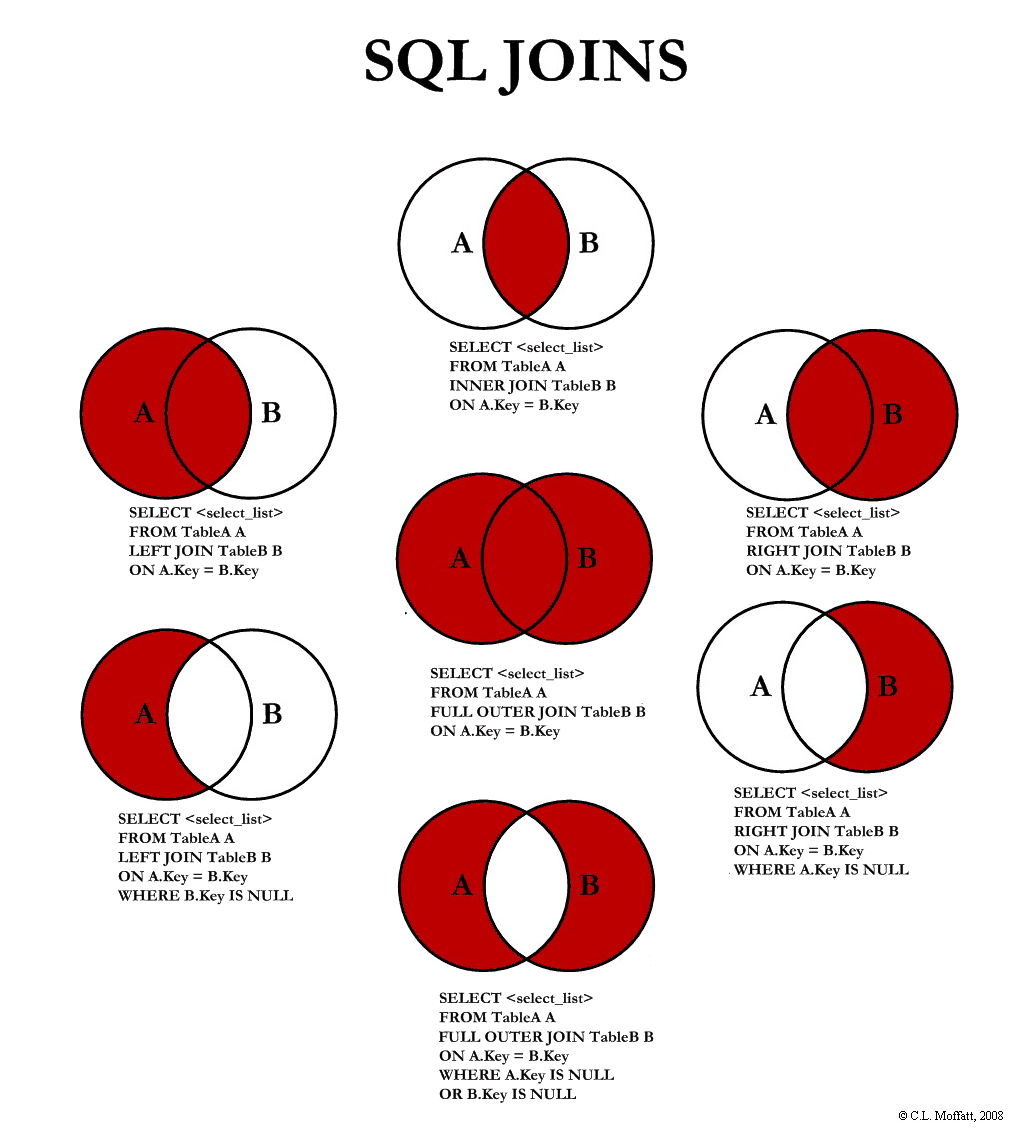

## 5.3 Объединения (CROSS JOIN, INNER JOIN)

In [131]:
# Загрузка скрипта с укороченной версией базы данных

connection = mysql.connector.connect(
    host='localhost',
    user='root',
    password='lolik`12*-',
)

cursor = connection.cursor()

with open(r'data/fulldb-short.sql', encoding="utf-8") as f:
    commands = f.read().split(';')

for command in commands:
    cursor.execute(command)
    print(command)

connection.close()

-- MariaDB dump 10.19  Distrib 10.11.7-MariaDB, for Linux (x86_64)
--
-- Host: mysql.hostinger.ro    Database: u574849695_23
-- ------------------------------------------------------
-- Server version	10.11.7-MariaDB-cll-lve

/*!40101 SET @OLD_CHARACTER_SET_CLIENT=@@CHARACTER_SET_CLIENT */

/*!40101 SET @OLD_CHARACTER_SET_RESULTS=@@CHARACTER_SET_RESULTS */

/*!40101 SET @OLD_COLLATION_CONNECTION=@@COLLATION_CONNECTION */

/*!40101 SET NAMES utf8mb4 */

/*!40103 SET @OLD_TIME_ZONE=@@TIME_ZONE */

/*!40103 SET TIME_ZONE='+00:00' */

/*!40014 SET @OLD_UNIQUE_CHECKS=@@UNIQUE_CHECKS, UNIQUE_CHECKS=0 */

/*!40014 SET @OLD_FOREIGN_KEY_CHECKS=@@FOREIGN_KEY_CHECKS, FOREIGN_KEY_CHECKS=0 */

/*!40101 SET @OLD_SQL_MODE=@@SQL_MODE, SQL_MODE='NO_AUTO_VALUE_ON_ZERO' */

/*!40111 SET @OLD_SQL_NOTES=@@SQL_NOTES, SQL_NOTES=0 */



DROP DATABASE IF EXISTS stepik

CREATE SCHEMA stepik

USE stepik


--
-- Table structure for table `channel_message_reactions`
--

DROP TABLE IF EXISTS users

CREATE TABLE use

## 5.4 Объединения (LEFT JOIN, RIGHT JOIN)

## 5.5 Объединения (FULL OUTER JOIN)

## 5.6 Вложенные запросы VS объединения

## 5.7 Соединения (UNION)

## 5.8 Оконные функции

## 5.9 Общие табличные выражения (CTE)

## 5.10 Рекурсивные табличные выражения

In [132]:
SELECT
    firstname,
    lastname,
    birthday,
    app_language
FROM users u
JOIN user_settings us
ON u.id = us.user_id
WHERE u.id = 10;

IndentationError: unexpected indent (4264975171.py, line 2)